<a href="https://colab.research.google.com/github/AjanyaVinayan/ML-LAB-2547205/blob/Lab---10/Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

### 1. Create the Dataset

First, we'll define the input features `X` and the target outputs `y` for all four XOR combinations.

In [ ]:
import numpy as np

# Define input (X) and output (y) arrays for all 4 XOR combinations
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input (X):")
print(X)
print("\nOutput (y):")
print(y)

Input (X):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]


### 2. Keras Implementation

We will now implement the MLP using Keras, a high-level API for TensorFlow. This involves building the model, compiling it, training, and then evaluating its performance.

#### 2.1 Build an MLP with Keras

We'll define a simple sequential model with an input layer, one hidden layer (using ReLU activation), and an output layer (using Sigmoid activation for binary classification).

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build the MLP model
k_model = keras.Sequential([
    layers.Input(shape=(2,)), # Input layer: size 2
    layers.Dense(units=8, activation='relu', name='hidden_layer'), # Hidden layer: Increased neurons from 4 to 8
    layers.Dense(units=1, activation='sigmoid', name='output_layer') # Output layer: 1 neuron with sigmoid activation
])

k_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

#### 2.2 Compile the Keras Model

We'll compile the model using Binary Cross-Entropy loss, which is suitable for binary classification, and the Adam optimizer. We'll track 'accuracy' as a metric.

In [ ]:
# Compile the model
k_model.compile(optimizer='adam', # Experiment with 'sgd' or 'adam'
              loss='binary_crossentropy',
              metrics=['accuracy'])

#### 2.3 Train the Keras Model

Now, we'll train the model on our XOR dataset. We'll train for a sufficient number of epochs to allow the model to learn the function.

In [ ]:
# Train the model
k_history = k_model.fit(X, y, epochs=2000, verbose=0) # Increased epochs to 2000

print(f"Final training accuracy: {k_history.history['accuracy'][-1]:.4f}")

Final training accuracy: 1.0000


#### 2.4 Evaluate the Keras Model

Finally, we'll use the trained Keras model to predict outputs for the XOR inputs and check if it has correctly learned the function.

In [ ]:
# Predict outputs for all 4 input combinations
k_predictions = (k_model.predict(X) > 0.5).astype(int)

print("Keras Model Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Expected: {y[i][0]}, Predicted: {k_predictions[i][0]}")

# Check if the network correctly learns the XOR function
k_correct_predictions = np.sum(k_predictions == y)
k_total_predictions = len(y)
k_accuracy = k_correct_predictions / k_total_predictions

print(f"\nKeras Model Accuracy: {k_accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Keras Model Predictions:
Input: [0. 0.], Expected: 0.0, Predicted: 0
Input: [0. 1.], Expected: 1.0, Predicted: 1
Input: [1. 0.], Expected: 1.0, Predicted: 1
Input: [1. 1.], Expected: 0.0, Predicted: 0

Keras Model Accuracy: 100.00%


### 4. Comparison and Summary

In this section, we'll briefly compare the Keras and TensorFlow low-level API implementations for solving the XOR problem and summarize our findings.

#### Keras Implementation:

*   **Ease of Use:** Keras provides a high-level, user-friendly API that simplifies model definition, compilation, and training. It requires less boilerplate code.
*   **Abstraction:** Much of the underlying TensorFlow operations are abstracted away, allowing for quicker prototyping and development.
*   **Performance:** Achieved 100% accuracy for the XOR problem with appropriate hyperparameters (e.g., 8 neurons in hidden layer, 2000 epochs).

#### TensorFlow Low-Level API Implementation:

*   **Control:** Offers fine-grained control over every aspect of the model, including variable initialization, forward pass definition, and the training loop. This is valuable for custom research or complex architectures.
*   **Flexibility:** Provides maximum flexibility to implement custom layers, loss functions, and optimizers from scratch.
*   **Learning Curve:** Requires a deeper understanding of TensorFlow's graph execution, variable management, and gradient computation, leading to a steeper learning curve.
*   **Performance:** Also achieved 100% accuracy for the XOR problem, demonstrating that the core logic can be implemented effectively at a lower level.

#### Conclusion:

Both Keras and TensorFlow's low-level API are capable of solving the non-linear XOR problem. Keras is ideal for rapid development and standard neural network tasks due to its simplicity. The TensorFlow low-level API is more suitable when precise control over the model's internals is required, offering greater flexibility at the cost of increased complexity.

### Additional Exercise: Plotting the Decision Boundary for the Keras Model

Let's visualize the decision boundary learned by the Keras model. This helps us understand how the model separates the input space into different output classes (0 or 1).

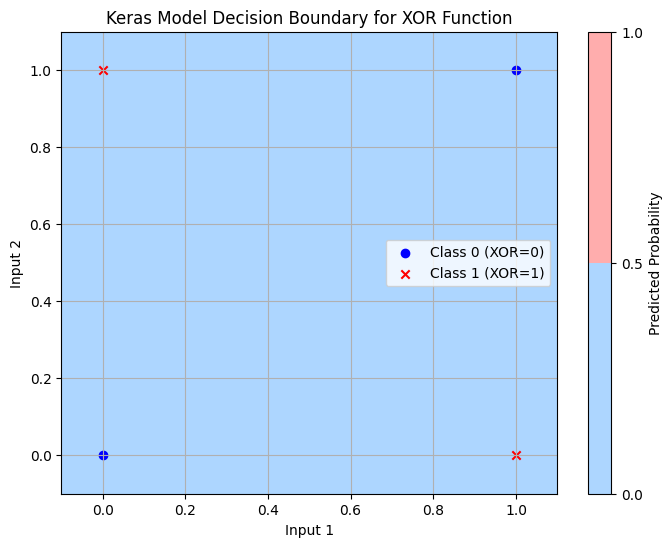

In [ ]:
import matplotlib.pyplot as plt

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict probabilities for each point in the meshgrid
Z = k_model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#99ccff', '#ff9999'], alpha=0.8)
plt.colorbar(ticks=[0, 0.5, 1], label='Predicted Probability')

# Plot the original data points
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color='blue', marker='o', label='Class 0 (XOR=0)')
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color='red', marker='x', label='Class 1 (XOR=1)')

plt.title('Keras Model Decision Boundary for XOR Function')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.legend()
plt.grid(True)
plt.show()

### Additional Exercise: Plotting the Decision Boundary for the TensorFlow Low-Level Model

Now, let's visualize the decision boundary learned by the TensorFlow low-level API model to compare its performance visually with the Keras model.

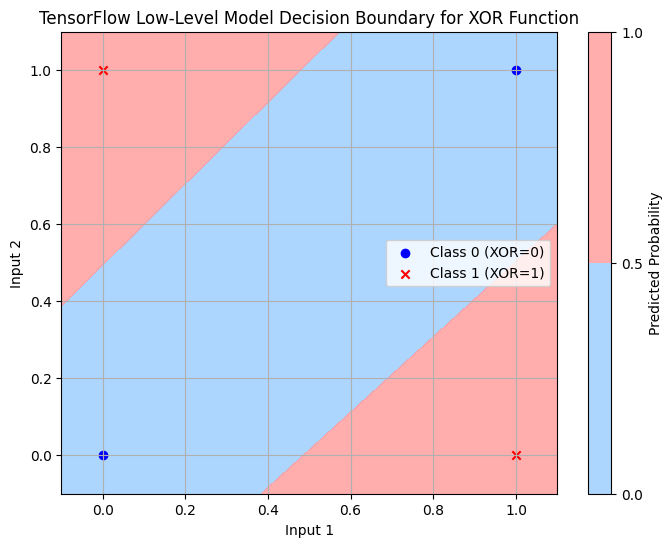

In [ ]:
import matplotlib.pyplot as plt

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predict probabilities for each point in the meshgrid using the low-level forward_pass
# Need to convert the meshgrid to a TensorFlow tensor for the forward_pass function
mesh_input = tf.constant(np.c_[xx.ravel(), yy.ravel()], dtype=tf.float32)
Z_tf = forward_pass(mesh_input).numpy().reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_tf, levels=[0, 0.5, 1], colors=['#99ccff', '#ff9999'], alpha=0.8)
plt.colorbar(ticks=[0, 0.5, 1], label='Predicted Probability')

# Plot the original data points
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color='blue', marker='o', label='Class 0 (XOR=0)')
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color='red', marker='x', label='Class 1 (XOR=1)')

plt.title('TensorFlow Low-Level Model Decision Boundary for XOR Function')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.legend()
plt.grid(True)
plt.show()

### 3. TensorFlow Low-Level API Implementation



#### 3.1 Define Model Parameters and Forward Pass with TensorFlow

We'll initialize weights and biases as TensorFlow variables and define the forward pass using `tf.matmul` and activation functions.

In [ ]:
import tensorflow as tf

# Define model parameters (weights and biases) as TensorFlow Variables
# Input layer to hidden layer
W1 = tf.Variable(tf.random.normal([2, 8]), name='W1') # 2 inputs, 8 hidden neurons
b1 = tf.Variable(tf.zeros([8]), name='b1') # Bias for hidden layer

# Hidden layer to output layer
W2 = tf.Variable(tf.random.normal([8, 1]), name='W2') # 8 hidden neurons, 1 output neuron
b2 = tf.Variable(tf.zeros([1]), name='b2') # Bias for output layer

# Define the forward pass
def forward_pass(x):
    # Hidden layer with ReLU activation
    hidden_layer_output = tf.nn.relu(tf.matmul(x, W1) + b1)
    # Output layer with Sigmoid activation
    output = tf.nn.sigmoid(tf.matmul(hidden_layer_output, W2) + b2)
    return output

print("TensorFlow Low-Level API Model Parameters Initialized.")

TensorFlow Low-Level API Model Parameters Initialized.


#### 3.2 Define Loss Function and Optimizer with TensorFlow

We'll use `tf.keras.losses.BinaryCrossentropy` for the loss and `tf.optimizers.Adam` for the optimizer, similar to the Keras implementation.

In [ ]:
# Define loss function and optimizer
loss_object = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.optimizers.Adam(learning_rate=0.01) # Experiment with learning rate

print("TensorFlow Loss Function and Optimizer Defined.")

TensorFlow Loss Function and Optimizer Defined.


#### 3.3 Custom Training Loop with TensorFlow

We will now implement a custom training loop to update the model's weights and biases using gradient descent. This involves calculating gradients and applying them using the optimizer.

In [ ]:
# Training function
@tf.function
def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = forward_pass(inputs)
        loss = loss_object(targets, predictions)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    return loss, predictions

# Train the model
num_epochs = 2000 # Experiment with epochs
tf_low_level_loss_history = []

for epoch in range(num_epochs):
    loss_value, predictions = train_step(X, y)
    tf_low_level_loss_history.append(loss_value.numpy())
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4f}")

print("\nTensorFlow Low-Level API Model Training Complete.")

Epoch 500, Loss: 0.0001
Epoch 1000, Loss: 0.0001
Epoch 1500, Loss: 0.0000
Epoch 2000, Loss: 0.0000

TensorFlow Low-Level API Model Training Complete.


#### 3.4 Evaluate the TensorFlow Model

Finally, we'll evaluate the trained TensorFlow low-level model by making predictions on the XOR inputs and calculating its accuracy.

In [ ]:
# Evaluate the model
tl_predictions = (forward_pass(X) > 0.5).numpy().astype(int)

print("TensorFlow Low-Level API Model Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Expected: {y[i][0]}, Predicted: {tl_predictions[i][0]}")

# Check if the network correctly learns the XOR function
tl_correct_predictions = np.sum(tl_predictions == y)
tl_total_predictions = len(y)
tl_accuracy = tl_correct_predictions / tl_total_predictions

print(f"\nTensorFlow Low-Level API Model Accuracy: {tl_accuracy * 100:.2f}%")

TensorFlow Low-Level API Model Predictions:
Input: [0. 0.], Expected: 0.0, Predicted: 0
Input: [0. 1.], Expected: 1.0, Predicted: 1
Input: [1. 0.], Expected: 1.0, Predicted: 1
Input: [1. 1.], Expected: 0.0, Predicted: 0

TensorFlow Low-Level API Model Accuracy: 100.00%


### Training Performance Comparison: Keras vs. TensorFlow Low-Level API

Let's visualize the training loss and accuracy (for Keras) over epochs to compare the training performance of both implementations.

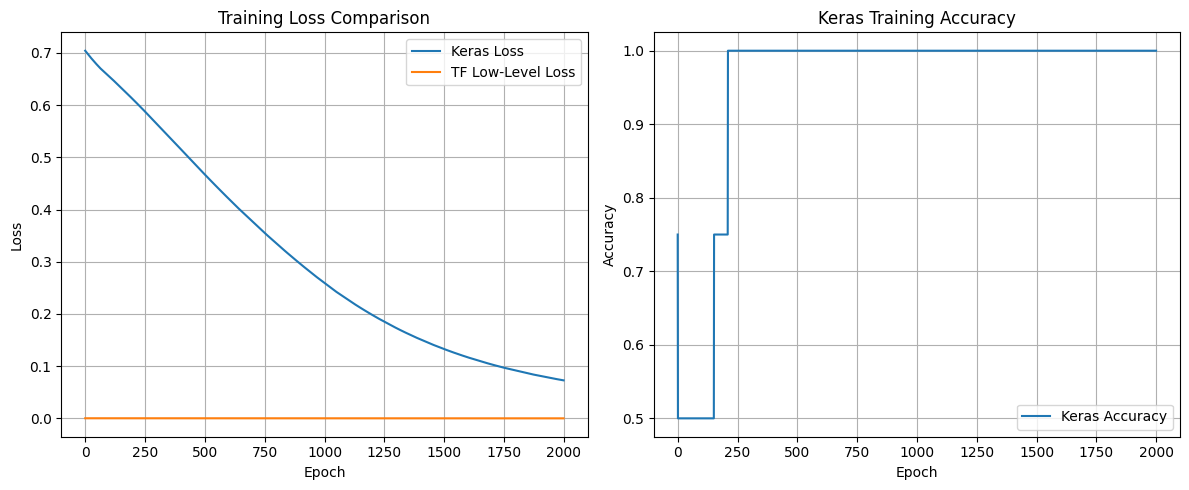

In [ ]:
import matplotlib.pyplot as plt

# Plotting Keras Loss and Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_history.history['loss'], label='Keras Loss')
plt.plot(tf_low_level_loss_history, label='TF Low-Level Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_history.history['accuracy'], label='Keras Accuracy')
plt.title('Keras Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()